In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import *

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy


In [76]:
!wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2024-04-12 07:35:41--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5085081 (4.8M) [text/csv]
Saving to: ‘bbc_text_cls.csv’

bbc_text_cls.csv    100%[===================>]   4.85M  --.-KB/s    in 0.1s    

2024-04-12 07:35:42 (46.2 MB/s) - ‘bbc_text_cls.csv’ saved [5085081/5085081]



In [77]:
df = pd.read_csv('bbc_text_cls.csv')

In [78]:
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [80]:
# map classes to integers from 0 to k-1
df['labels'].astype('category').cat.codes

0       0
1       0
2       0
3       0
4       0
       ..
2220    4
2221    4
2222    4
2223    4
2224    4
Length: 2225, dtype: int8

In [81]:
df['targets'] = df['labels'].astype("category").cat.codes

In [82]:
df_train, df_test = train_test_split(df, test_size = 0.3)

In [83]:
tfidf = TfidfVectorizer(stop_words='english')
Xtrain = tfidf.fit_transform(df_train['text'])
Xtest = tfidf.transform(df_test['text'])

In [84]:
Ytrain = df_train['targets']
Ytest = df_test['targets']

In [85]:
# number of classes

K = df['targets'].max() + 1
K

5

In [86]:
# imput dimensions

D = Xtrain.shape[1]

In [87]:
# build model
i = Input(shape=(D,))
x = Dense(300, activation = 'relu')(i)
x = Dense(K)(x)

model = Model(i,x )

In [88]:
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 24933)]           0         
                                                                 
 dense_2 (Dense)             (None, 300)               7480200   
                                                                 
 dense_3 (Dense)             (None, 5)                 1505      
                                                                 
Total params: 7481705 (28.54 MB)
Trainable params: 7481705 (28.54 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [89]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [90]:
Xtrain = Xtrain.toarray()
Xtest = Xtest.toarray()

In [92]:
r = model.fit(
    Xtrain, Ytrain,
    validation_data = (Xtest, Ytest),
    epochs = 5,
    batch_size = 32
)

Epoch 1/5
49/49 [==============================] - 10s 194ms/step - loss: 0.0064 - accuracy: 1.0000 - val_loss: 0.0806 - val_accuracy: 0.9805
Epoch 2/5
49/49 [==============================] - 9s 176ms/step - loss: 0.0047 - accuracy: 1.0000 - val_loss: 0.0768 - val_accuracy: 0.9820
Epoch 3/5
49/49 [==============================] - 9s 189ms/step - loss: 0.0036 - accuracy: 1.0000 - val_loss: 0.0736 - val_accuracy: 0.9820
Epoch 4/5
49/49 [==============================] - 9s 194ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.0713 - val_accuracy: 0.9835
Epoch 5/5
49/49 [==============================] - 9s 186ms/step - loss: 0.0024 - accuracy: 1.0000 - val_loss: 0.0694 - val_accuracy: 0.9835


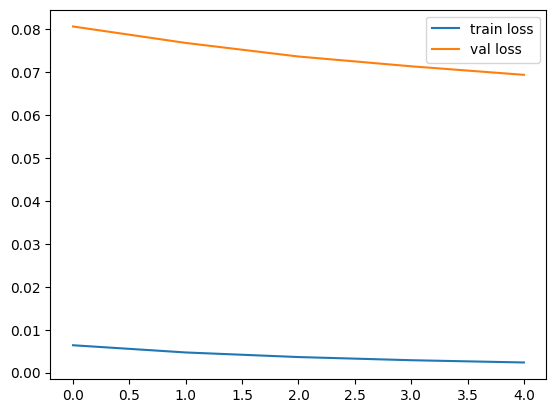

In [93]:

# Plot loss per iteration

plt.plot(r.history['loss'], label = 'train loss')
plt.plot(r.history['val_loss'], label = 'val loss')
plt.legend()


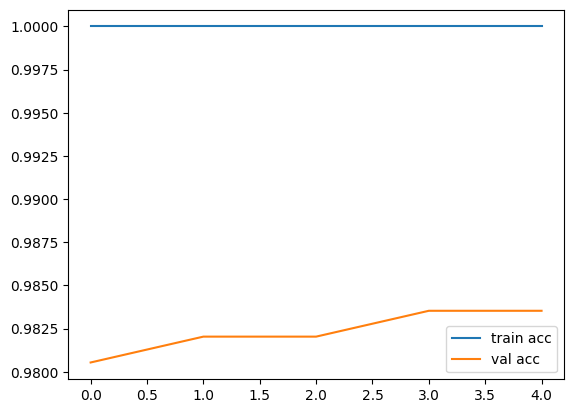

In [94]:
# Plot accuracy per iteration

plt.plot(r.history['accuracy'], label = 'train acc')
plt.plot(r.history['val_accuracy'], label = 'val acc')
plt.legend()

In [96]:
P_train = ((model.predict(Xtrain) > 0)*1.0).flatten()
P_test = ((model.predict(Xtest) > 0)*1.0).flatten()

21/21 [==============================] - 1s 35ms/step


In [98]:
cm = confusion_matrix(Ytrain, P_train, normalize = 'true')
cm

ValueError: Found input variables with inconsistent numbers of samples: [1557, 7785]

In [99]:
def plot_cm(cm):
  classes = ['positive','negative']
  df_cm = pd.DataFrame(cm, index = classes, columns = classes)
  ax = sns.heatmap(df_cm, annot = True, fmt = 'g')
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Target')


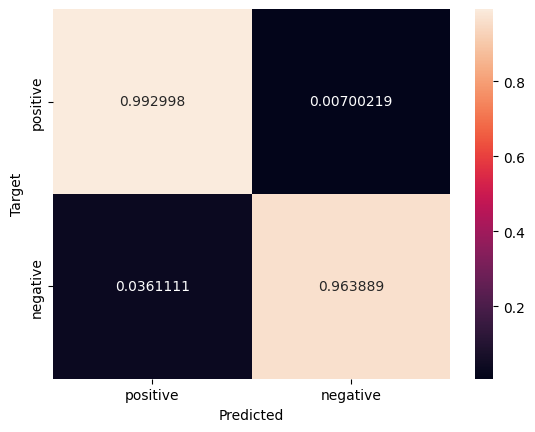

In [100]:
plot_cm(cm)


In [ ]:
Pr_train = model.predict(X_train)
Pr_test = model.predict(X_test)
print("Train AUC:", roc_auc_score(Y_train, Pr_train))
print("Test AUC:", roc_auc_score(Y_test, Pr_test))

In [ ]:
print('Train F1:', f1_score(Y_train, P_train))
print('Test F1:', f1_score(Y_test, P_test))